In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transformers import pipeline
from tqdm import tqdm


# Load the skill extraction model
print("Loading skill extraction model...")
skill_extractor = pipeline(
    "token-classification",
    model="GalalEwida/LLM-BERT-Model-Based-Skills-Extraction-from-jobdescription",
    aggregation_strategy="simple"
)
print("✓ Model loaded")



Loading skill extraction model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/265M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

✓ Model loaded


In [ ]:
df = pd.read_csv('/content/jobs.csv')
print(f"Loaded {len(df)} jobs")

Loaded 1062 jobs


In [ ]:

import re

def extract_relevant_section(text):
    """
    Remove company introduction and extract only relevant parts:
    missions, responsibilities, qualifications
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Keywords that mark START of relevant content (French & English)
    start_keywords = [
        r'mission',
        r'vos challenges',
        r'votre mission',
        r'description du poste',
        r'missions principales',
        r'vos missions',
        r'responsabilités',
        r'responsabilites',
        r'about the role',
        r'what you.?ll do',
        r'responsibilities',
        r'job description',
        r'your missions',
        r'key responsibilities',
        r'votre profil',
        r'your profile',
        r'qualifications',
        r'requirements',
        r'profil recherché',
        r'profil recherche',
        r'compétences',
        r'competences',
        r'what we.?re looking for',
        r'what you.?ll bring',
        r'required skills',
        r'your responsibilities',
    ]

    text_lower = text.lower()
    start_idx = len(text)

    # Find the earliest matching keyword
    for keyword in start_keywords:
        match = re.search(keyword, text_lower)
        if match:
            start_idx = min(start_idx, match.start())

    # If no keyword found, return full text
    if start_idx == len(text):
        return text

    # Return text from relevant section onwards
    return text[start_idx:]

# Apply the function
print("Removing company introductions...")
df['relevant_section'] = df['description'].apply(extract_relevant_section)
print(f"✓ Extracted relevant sections")



Removing company introductions...
✓ Extracted relevant sections


In [ ]:
import re

KNOWN_ACRONYMS = {
    'ai', 'aws', 'sql', 'git', 'nlp', 'crm', 'css', 'ux', 'etl', 'gcp',
    'cms', 'php', 'oop', 'uml', 'seo', 'iam', 'go', 'xml', 'api', 'bi',
    'ml', 'rpa', 'erp', 'llm', 'ui', 'hr', 'saas', 'paas', 'iot', 'sdk',
    'cli', 'rest', 'orm', 'asp',
}

def extract_unique_skills(text):
    """Extract skills from text and remove redundancy"""
    if pd.isna(text) or len(str(text)) < 50:
        return []
    text = str(text)[:3000]
    try:
        ents = skill_extractor(text)
        unique_skills = []
        seen = set()

        VALID_SHORT = {'ai', 'ml', 'ci', 'cd', 'ux', 'ui', 'go', 'dl', 'r', 'c'}

        for e in ents:
            skill = e["word"].strip()
            skill_lower = skill.lower()

            # FIX 1: Skip WordPiece subword fragments (##xxx)
            if skill_lower.startswith('##'):
                continue

            # FIX 2: Skip short tokens unless they're valid acronyms
            if len(skill) < 2:
                continue
            if len(skill) <= 2 and skill_lower not in VALID_SHORT:
                continue

            if skill_lower in seen:
                continue

            is_redundant = False
            for existing in unique_skills:
                if skill_lower in existing.lower() and skill_lower != existing.lower():
                    is_redundant = True
                    break

            if is_redundant:
                continue

            unique_skills = [
                s for s in unique_skills
                if not (s.lower() in skill_lower and s.lower() != skill_lower)
            ]
            unique_skills.append(skill)
            seen.add(skill_lower)

        return unique_skills

    except Exception as e:
        print(f"Error extracting skills: {e}")
        return []

In [ ]:
print("\nExtracting skills from job descriptions...")
print("This may take a few minutes...")

tqdm.pandas()

# FIX: fallback to full description if relevant_section yields nothing
def extract_with_fallback(row):
    skills = extract_unique_skills(row['relevant_section'])
    if not skills:
        skills = extract_unique_skills(row['description'])
    return skills

df['extracted_skills_list'] = df.progress_apply(extract_with_fallback, axis=1)

# Convert list to comma-separated string for easier viewing
df['extracted_skills'] = df['extracted_skills_list'].apply(
    lambda x: ', '.join(x) if x else ''
)

# Count number of skills per job
df['num_skills'] = df['extracted_skills_list'].apply(len)

print(f"\n✓ Skill extraction complete!")
print(f"Jobs with skills extracted: {(df['num_skills'] > 0).sum()}/{len(df)}")
print(f"Average skills per job: {df['num_skills'].mean():.1f}")

# Show sample
print("\nSample extracted skills:")
sample = df[df['num_skills'] > 0][['title', 'final_category', 'extracted_skills']].head(5)
for idx, row in sample.iterrows():
    print(f"\n{row['title']} ({row['final_category']}):")
    print(f"  Skills: {row['extracted_skills']}")


Extracting skills from job descriptions...
This may take a few minutes...


100%|██████████| 1062/1062 [12:46<00:00,  1.39it/s]


✓ Skill extraction complete!
Jobs with skills extracted: 888/1062
Average skills per job: 7.0

Sample extracted skills:

BI / Data Engineer (Data Science & ML):
  Skills: analytics, specifications, etl, dashboards, tests, sql

Data Engineer (Data Science & ML):
  Skills: java, dataset, sql, spring boot, scala, micro, cd, git

Data Engineer [F/M/X] (Data Science & ML):
  Skills: data engineering, operational data, agile environment, data pipelines, azure, etl, analytics, data processing, synapse, dataflow, data ingestion, datasets, dashboards, reporting, feature engineering, machine learning, sql, cost, python, performance tuning, scrum, devops, cd, data science, optimization

Data Analyst (BI & Data Analysis):
  Skills: statistical, modeling, unstructured, datasets, technical requirements, data management, data visualization, dashboards, orthopedics

Junior AI Engineer (Data Science & ML):
  Skills: nlp, integration, planning, machine learning, scikit - learn, spacy, python, pandas, n

In [ ]:
NOISE_WORDS = {
    # Generic business terms
    'reporting', 'administration', 'planning', 'optimization', 'ka',
    'methodology', 'specifications', 'information systems', 'sourcing',
    'forecasting', 'budgeting', 'forecasts', 'variance', 'operational support',
    'case management', 'quality', 'risk', 'screening', 'log', 'logs', '##iti',
    'after', 'software', 'automation', 'technology', 'application', 'production',
    'data', 'integration', 'tests', 'testing', 'informati',
    'computer science', 'computer engineering', 'software development',
    'product management', 'business analysis', 'technical support',
    'application support', 'it operations', 'risk analysis',
    'data collection', 'data analysis', 'data management', 'data engineering',
    'data visualization', 'data science', 'financial analysis',
    'technology transformation', 'dynamics', 'automotive', '##se',
    # NEW: ambiguous short tokens
    'gen', 'ku', 'aw', 'ia', 'ops', 'dev', 'opt', 'dl', 'cr', 'gi',
    'so', 'sa', 'et', 'ty', 'fm', 'micro',
    '##se', '##ati', '##flow', '##secu', '##apse', '##m', '##ops',
    '##iti', '##ing', '##ed', '##er',

    # Meaningless short fragments
    'ka', 'gi', 'sp', 'et', 'na', 'le', 'de',
}

MERGE_MAP = {
    'ci': 'CI/CD', 'cd': 'CI/CD', 'ci cd': 'CI/CD',
    'cicd': 'CI/CD', 'ci/cd': 'CI/CD',
    'rest': 'REST API', 'rest api': 'REST API', 'restful': 'REST API',
    'ml': 'Machine Learning', 'machine learning': 'Machine Learning',
    'ai': 'AI', 'artificial intelligence': 'AI',
    'git': 'Git', 'github': 'GitHub', 'gitlab': 'GitLab',
    'aws': 'AWS', 'gcp': 'GCP', 'sql': 'SQL', 'nosql': 'NoSQL',
    'nlp': 'NLP', 'ux': 'UX', 'ui': 'UI', 'bi': 'BI', 'etl': 'ETL',
    'api': 'API', 'saas': 'SaaS',
    'kubernetes': 'Kubernetes', 'k8s': 'Kubernetes',
}

def clean_and_merge_skills(skill_counts):
    cleaned = Counter()
    for skill, count in skill_counts.items():
        skill_lower = skill.lower().strip()
        if skill_lower in NOISE_WORDS:
            continue
        if skill_lower in MERGE_MAP:
            cleaned[MERGE_MAP[skill_lower]] += count
            continue
        cleaned[skill] = count
    return cleaned

In [ ]:
print("\n" + "="*70)
print("AGGREGATING SKILLS BY DOMAIN (WITH CLEANING)")
print("="*70)

# Filter to categories with 10+ jobs
category_counts = df['final_category'].value_counts()
valid_categories = category_counts[category_counts >= 10].index.tolist()
if 'Other' in valid_categories:
    valid_categories.remove('Other')

df_filtered = df[df['final_category'].isin(valid_categories)].copy()

# Collect all skills per category
category_skills = {}

for category in valid_categories:
    category_jobs = df_filtered[df_filtered['final_category'] == category]

    # Collect all skills from all jobs in this category
    all_skills = []
    for skills_list in category_jobs['extracted_skills_list']:
        all_skills.extend(skills_list)

    # Count skill frequency
    skill_counts = Counter(all_skills)

    # CLEAN THE SKILLS HERE
    skill_counts = clean_and_merge_skills(skill_counts)

    # Store top 20 skills
    category_skills[category] = skill_counts.most_common(20)

    print(f"\n{category} ({len(category_jobs)} jobs):")
    print(f"  Total skills extracted: {len(all_skills)}")
    print(f"  Unique skills (after cleaning): {len(skill_counts)}")
    print(f"  Top 10: {', '.join([s for s, c in skill_counts.most_common(10)])}")


AGGREGATING SKILLS BY DOMAIN (WITH CLEANING)

Software Engineering (218 jobs):
  Total skills extracted: 2188
  Unique skills (after cleaning): 272
  Top 10: CI/CD, python, Git, angular, docker, REST API, postgresql, Kubernetes, version control, scrum

Business & Operations (148 jobs):
  Total skills extracted: 376
  Unique skills (after cleaning): 106
  Top 10: crm, SaaS, AI, python, java, networking, economics, servers, AWS, jira

IT & Security (145 jobs):
  Total skills extracted: 555
  Unique skills (after cleaning): 137
  Top 10: troubleshooting, security, AI, REST API, SaaS, azure, devops, computing, linux, cybersecurity

Data Science & ML (144 jobs):
  Total skills extracted: 1535
  Unique skills (after cleaning): 210
  Top 10: python, Machine Learning, AI, azure, NLP, docker, CI/CD, SQL, devops, tensorflow

Project Management (92 jobs):
  Total skills extracted: 392
  Unique skills (after cleaning): 92
  Top 10: jira, crm, scrum, CI/CD, devops, jenkins, contingency, go, versio

In [ ]:
df_save = df.copy()
df_save['extracted_skills_list'] = df_save['extracted_skills_list'].apply(
    lambda skills: [
        MERGE_MAP.get(s.lower().strip(), s)          # apply merge map
        for s in skills
        if s.lower().strip() not in NOISE_WORDS      # filter noise
        and not re.match(r'^##', s)                  # filter artifacts
        and not (len(s) <= 2 and s.lower() not in KNOWN_ACRONYMS)  # filter short tokens
    ]
)
df_save['extracted_skills'] = df_save['extracted_skills_list'].apply(
    lambda x: ', '.join(x) if x else ''
)
# NEW: drop rows where no skills could be extracted at all
# Build category top skills for fallback
category_top_skills = {}
for category, skills in category_skills.items():
    category_top_skills[category] = [s for s, c in skills[:10]]

# Flag which jobs have real skills vs inferred
df_save['has_skills'] = df_save['extracted_skills'] != ''

# Fill empty skills from category average
def fill_missing_skills(row):
    if row['extracted_skills_list']:
        return row['extracted_skills_list'], True   # real skills
    category = row.get('final_category', '')
    fallback = category_top_skills.get(category, [])
    return fallback, False  # inferred skills

result = df_save.apply(fill_missing_skills, axis=1)
df_save['extracted_skills_list'] = result.apply(lambda x: x[0])
df_save['skills_are_real'] = result.apply(lambda x: x[1])
df_save['extracted_skills'] = df_save['extracted_skills_list'].apply(
    lambda x: ', '.join(x) if x else ''
)

print(f"Total jobs kept: {len(df_save)}")
print(f"Jobs with real skills: {df_save['skills_are_real'].sum()}")
print(f"Jobs with inferred skills: {(~df_save['skills_are_real']).sum()}")

df_save.to_csv('linkedin_jobs_with_extracted_skills_per_job4.csv', index=False)
print(f"✓ Saved {len(df_save)} jobs")

Total jobs kept: 1062
Jobs with real skills: 747
Jobs with inferred skills: 315
✓ Saved 1062 jobs


In [ ]:
summary_data = []

for category, skills in category_skills.items():
    num_jobs = len(df_filtered[df_filtered['final_category'] == category])

    top_10 = [s for s, c in skills[:10]]
    top_20 = [s for s, c in skills[:20]]

    summary_data.append({
        'domain': category,
        'num_jobs': num_jobs,
        'unique_skills': len(skills),
        'top_10_skills': ', '.join(top_10),
        'top_20_skills': ', '.join(top_20)
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('num_jobs', ascending=False)

print("\n" + "="*70)
print("SKILLS SUMMARY BY DOMAIN")
print("="*70)
print(summary_df[['domain', 'num_jobs', 'unique_skills', 'top_10_skills']])

summary_df.to_csv('skills_by_domain_summary.csv', index=False)
print(f"\n✓ Saved to 'skills_by_domain_summary.csv'")



SKILLS SUMMARY BY DOMAIN
                  domain  num_jobs  unique_skills  \
0   Software Engineering       218             20   
1  Business & Operations       148             20   
2          IT & Security       145             20   
3      Data Science & ML       144             20   
4     Project Management        92             20   
5         DevOps & Cloud        80             20   
6    IT Consulting & ERP        72             20   
7     BI & Data Analysis        66             20   
8      Design & Graphics        54             20   
9           QA & Testing        43             20   

                                       top_10_skills  
0  CI/CD, python, Git, angular, docker, REST API,...  
1  crm, SaaS, AI, python, java, networking, econo...  
2  troubleshooting, security, AI, REST API, SaaS,...  
3  python, Machine Learning, AI, azure, NLP, dock...  
4  jira, crm, scrum, CI/CD, devops, jenkins, cont...  
5  devops, CI/CD, docker, AWS, azure, security, A...  
6  SQ


CREATING VISUALIZATIONS
✓ Saved visualization to 'top_skills_by_domain.png'


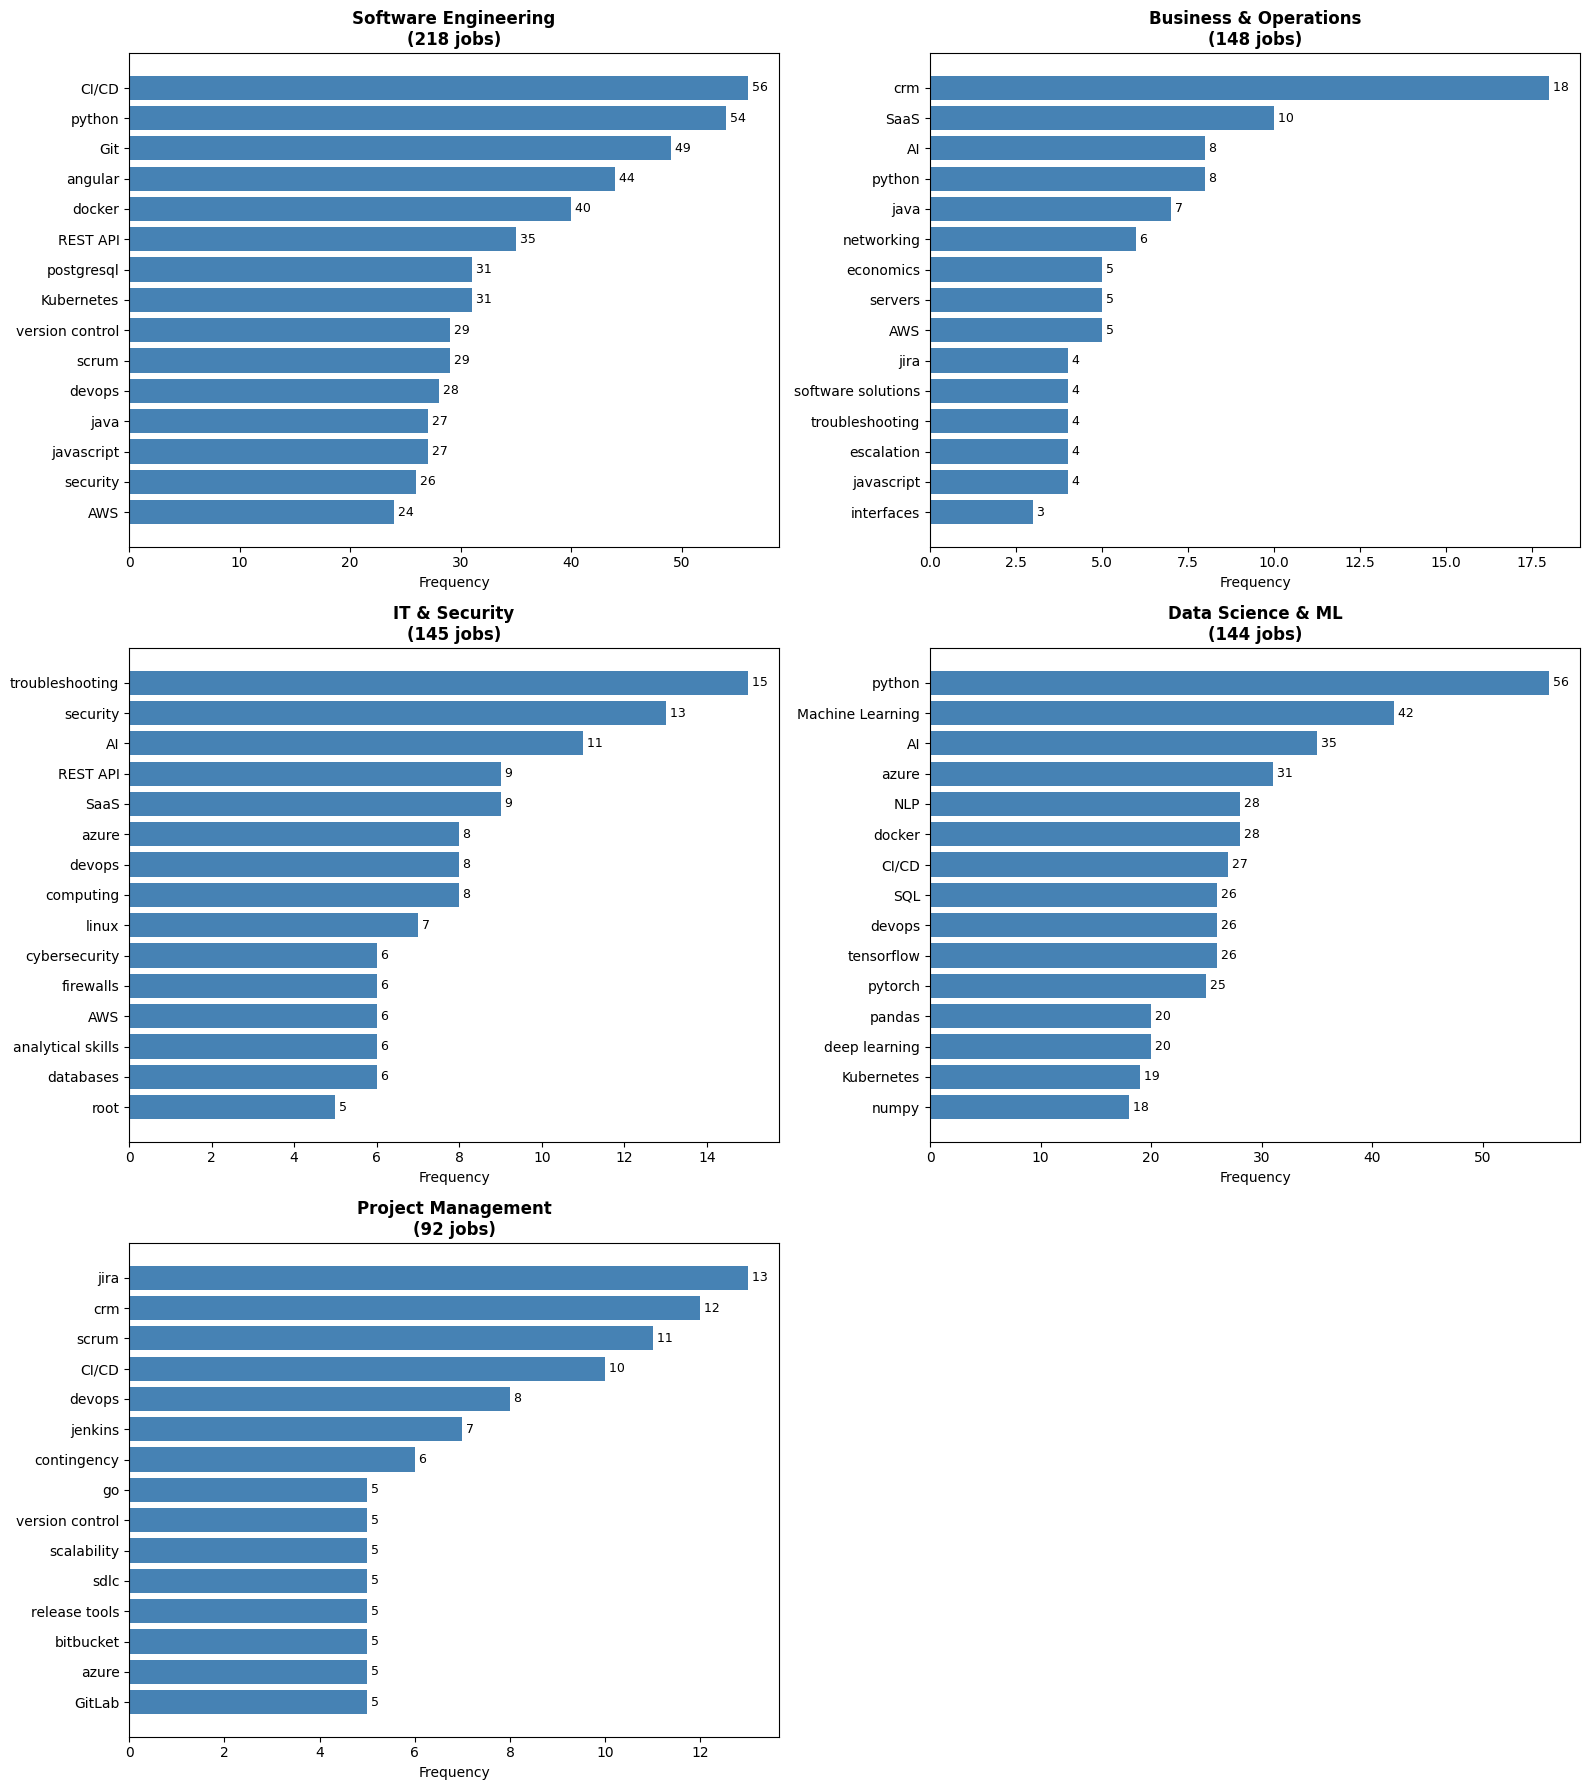

In [ ]:
print("\n" + "="*70)
print("CREATING VISUALIZATIONS")
print("="*70)

# Get top 5 domains by job count
top_5_domains = summary_df.head(5)['domain'].tolist()

# Create subplots for top 5 domains
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, domain in enumerate(top_5_domains):
    skills = category_skills[domain][:15]  # Top 15 skills

    skill_names = [s for s, c in skills]
    skill_counts = [c for s, c in skills]

    # Plot horizontal bar chart
    axes[idx].barh(skill_names, skill_counts, color='steelblue')
    axes[idx].set_xlabel('Frequency', fontsize=10)
    axes[idx].set_title(f'{domain}\n({category_counts[domain]} jobs)',
                        fontsize=12, fontweight='bold')
    axes[idx].invert_yaxis()

    # Add count labels
    for i, (skill, count) in enumerate(zip(skill_names, skill_counts)):
        axes[idx].text(count, i, f' {count}', va='center', fontsize=9)

# Remove empty subplot
if len(top_5_domains) < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('top_skills_by_domain.png', dpi=300, bbox_inches='tight')
print("✓ Saved visualization to 'top_skills_by_domain.png'")
plt.show()

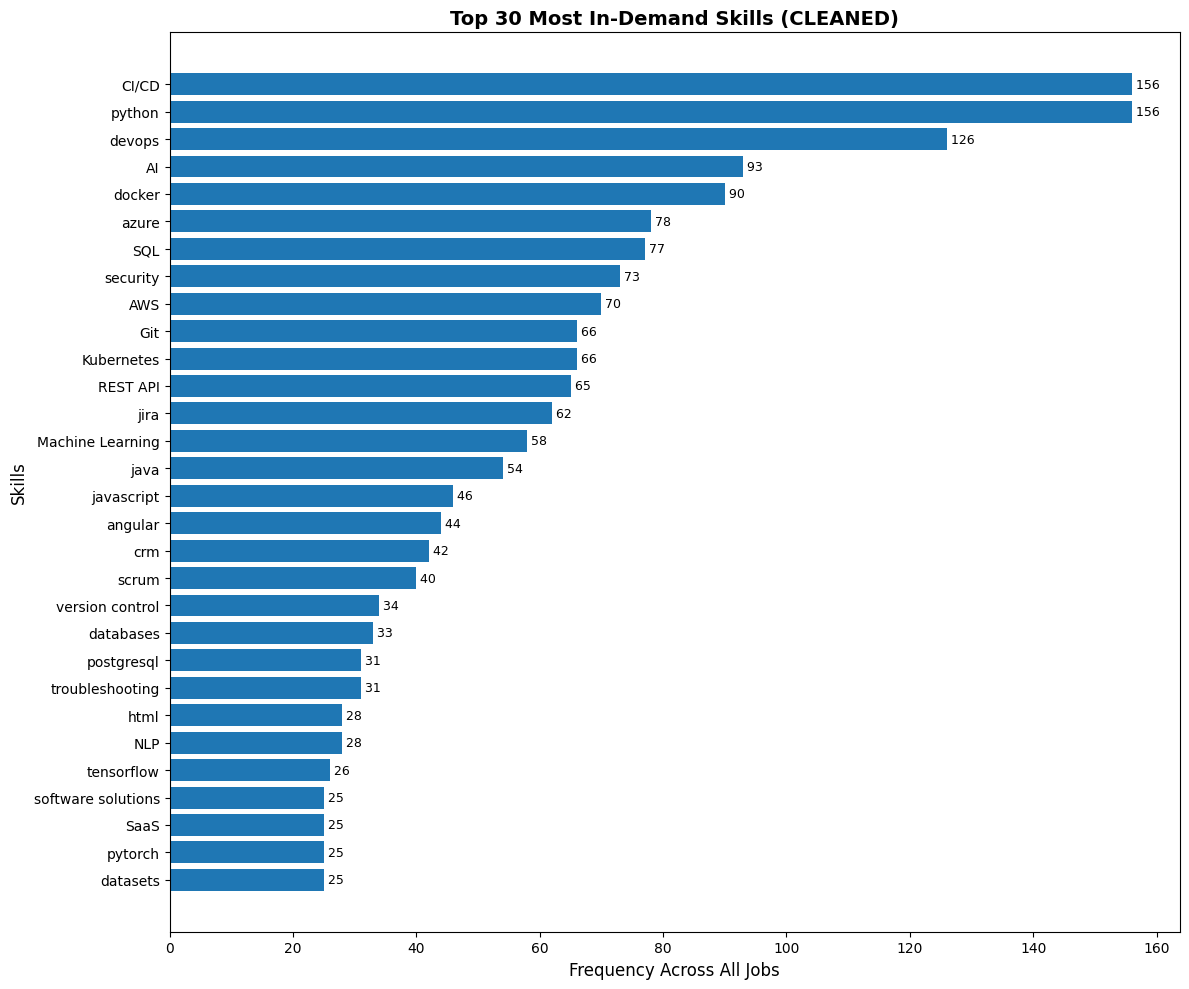

In [ ]:
all_cleaned_skills = []

for category, skills in category_skills.items():
    for skill, count in skills:
        all_cleaned_skills.extend([skill] * count)
overall_skill_counts = Counter(all_cleaned_skills)
top_30_overall = overall_skill_counts.most_common(30)


plt.figure(figsize=(12, 10))

skills = [s for s, c in top_30_overall]
counts = [c for s, c in top_30_overall]

plt.barh(skills, counts)
plt.xlabel('Frequency Across All Jobs', fontsize=12)
plt.ylabel('Skills', fontsize=12)
plt.title('Top 30 Most In-Demand Skills (CLEANED)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

for i, (skill, count) in enumerate(zip(skills, counts)):
    plt.text(count, i, f' {count}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_skills_overall_cleaned.png', dpi=300, bbox_inches='tight')
plt.show()
